In [67]:
import polars as pl
import torch
import torch.nn.functional as F
import umap
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, PrecisionRecallDisplay
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import Lasso
import numpy as np
import seaborn as sns

from amaretto_mlp import *
from utils_b import *
from autoencoder import *
from explanation import *
from visualization import *


%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
pl.Config.set_tbl_cols(150) 

polars.config.Config

In [3]:
df = pl.read_parquet("amaretto_transformed_scaled.pq")
df = df.with_columns(((pl.col('hour') >= 2) & (pl.col('hour') < 5)).alias('unusual_hour'))
df_train, df_val, df_test = split_data(df)

#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime']
#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute']
columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute', 'day_of_month_cos', 'minute_cos', 'day_of_month_sin', 'minute_sin']


target_column = 'Anomaly_bin'
y_train = df_train.select(target_column).to_numpy().flatten()
y_train_anomalies = df_train.select('Anomaly').to_numpy().flatten()
df_train = df_train.drop(columns_to_drop)
X_train = df_train.to_numpy()
y_val = df_val.select(target_column).to_numpy().flatten()
X_val = df_val.drop(columns_to_drop).to_numpy()
y_test = df_test.select(target_column).to_numpy().flatten()
y_test_anomalies = df_test.select('Anomaly').to_numpy().flatten()

X_test = df_test.drop(columns_to_drop).to_numpy()

train_dataset = AmarettoDataset(X_train, y_train)
val_dataset = AmarettoDataset(X_val, y_val)
test_dataset = AmarettoDataset(X_test, y_test)
feature_names = df_train.columns
print(X_train.shape)
print(X_test.shape)

(24451934, 118)
(2765755, 118)


In [4]:
train_loader = DataLoader(train_dataset, batch_size=256, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=256, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, num_workers=2)
input_dim = X_train.shape[1]
df_train, df_val, df_test = split_data(df)
print(len(train_loader))

95516


In [5]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)
class_weights

tensor([  0.5014, 180.1141])

In [ ]:
model_combined = train_combined(train_loader, val_loader, input_dim, hidden_layers=[64, 64], latent_dim=16, num_classes=2, epochs=10, lr=0.0001, alpha=0.5, class_weights=class_weights)

Epoch 1/10 [Training]:   0%|          | 0/95516 [00:00<?, ?it/s]

Epoch 1: Train Loss = 0.1469, Val Loss = 0.2659
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.47      0.93      0.62      6708

    accuracy                           1.00   2486401
   macro avg       0.73      0.96      0.81   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.8102


Epoch 2/10 [Training]:   0%|          | 0/95516 [00:00<?, ?it/s]

Epoch 2: Train Loss = 0.0963, Val Loss = 0.2683
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.62      0.93      0.75      6708

    accuracy                           1.00   2486401
   macro avg       0.81      0.96      0.87   2486401
weighted avg       1.00      1.00      1.00   2486401

New best model saved with Macro F1 = 0.8725


Epoch 3/10 [Training]:   0%|          | 0/95516 [00:00<?, ?it/s]

Epoch 3: Train Loss = 0.0876, Val Loss = 0.2651
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.55      0.93      0.69      6708

    accuracy                           1.00   2486401
   macro avg       0.78      0.97      0.85   2486401
weighted avg       1.00      1.00      1.00   2486401



Epoch 4/10 [Training]:   0%|          | 0/95516 [00:00<?, ?it/s]

In [6]:
model = CombinedModel(input_dim=X_train.shape[1], hidden_layers=[64, 64], latent_dim=16, num_classes=2)
model.load_state_dict(torch.load("model_combined_best_bin.pth"))
print(model)

CombinedModel(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=118, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=118, bias=True)
    )
  )
  (classifier): Classifier(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=2, bias=True)
    )
  )
)


In [56]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    _, y_logits, z_train = model(X_train_tensor)
    y_probs_train = F.softmax(y_logits, dim=1)
    y_pred_train = torch.argmax(y_probs_train, dim=1)
y_pred_train = y_pred_train.cpu().numpy()
y_probs_train = y_probs_train.cpu().numpy()
print(y_pred_train.shape)
z_train = z_train.cpu().numpy()
print(z_train.shape)

(24451934,)
(24451934, 16)


In [58]:
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, y_logits, z_test = model(X_test_tensor)
    y_probs_test = F.softmax(y_logits, dim=1)
    y_pred_test = torch.argmax(y_probs_test, dim=1)
y_pred_test = y_pred_test.cpu().numpy()
y_probs_test = y_probs_test.cpu().numpy()
print(y_pred_test.shape)
z_test = z_test.cpu().numpy()
print(z_test.shape)

(2765755,)
(2765755, 16)


In [59]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00  24384055
           1       0.34      0.95      0.50     67879

    accuracy                           0.99  24451934
   macro avg       0.67      0.97      0.75  24451934
weighted avg       1.00      0.99      1.00  24451934



In [60]:
print(confusion_matrix(y_train, y_pred_train))

[[24257290   126765]
 [    3424    64455]]


In [61]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2759074
           1       0.70      0.93      0.80      6681

    accuracy                           1.00   2765755
   macro avg       0.85      0.96      0.90   2765755
weighted avg       1.00      1.00      1.00   2765755



In [62]:
print(confusion_matrix(y_test, y_pred_test))

[[2756414    2660]
 [    476    6205]]


In [14]:
z_sampled, y_true_sampled, selected_indices = sample_data(z_test, y_test, n_samples=10000, anomaly_ratio=0.3)
y_pred_sampled = y_pred_test[selected_indices]
y_test_anomalies_sampled = y_test_anomalies[selected_indices]

[6681]
7000
2759074
7000


In [15]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(z_sampled)
embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(10000, 2)

In [16]:
all_labels = np.array([0, 1, 2, 3, 4, 5])
set1_colors = sns.color_palette("Set1", n_colors=len(all_labels))
custom_palette = ["#A0A0A0"] + set1_colors[1:]

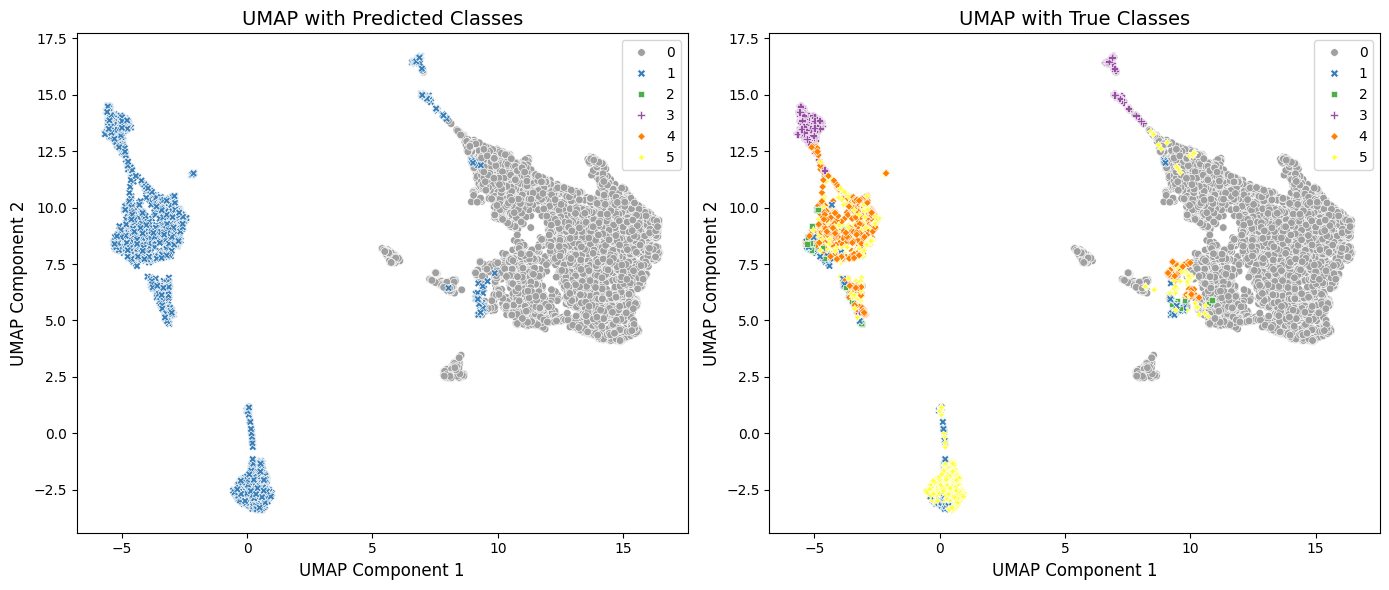

In [17]:
plot_comparison_all(embedding, y_pred_sampled, y_test_anomalies_sampled, 
                custom_palette, all_labels, "UMAP", save_path="figs/combined_model_bin_pred_classes_umap.png")

In [20]:
z_test_a = z_test[y_pred_test != 0]
y_test_a = y_test[y_pred_test != 0]
y_pred_test_a = y_pred_test[y_pred_test != 0]
y_pred_test_anomalies_a = y_test_anomalies[y_pred_test != 0]

embedding = reducer.fit_transform(z_test_a)
embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(8865, 2)

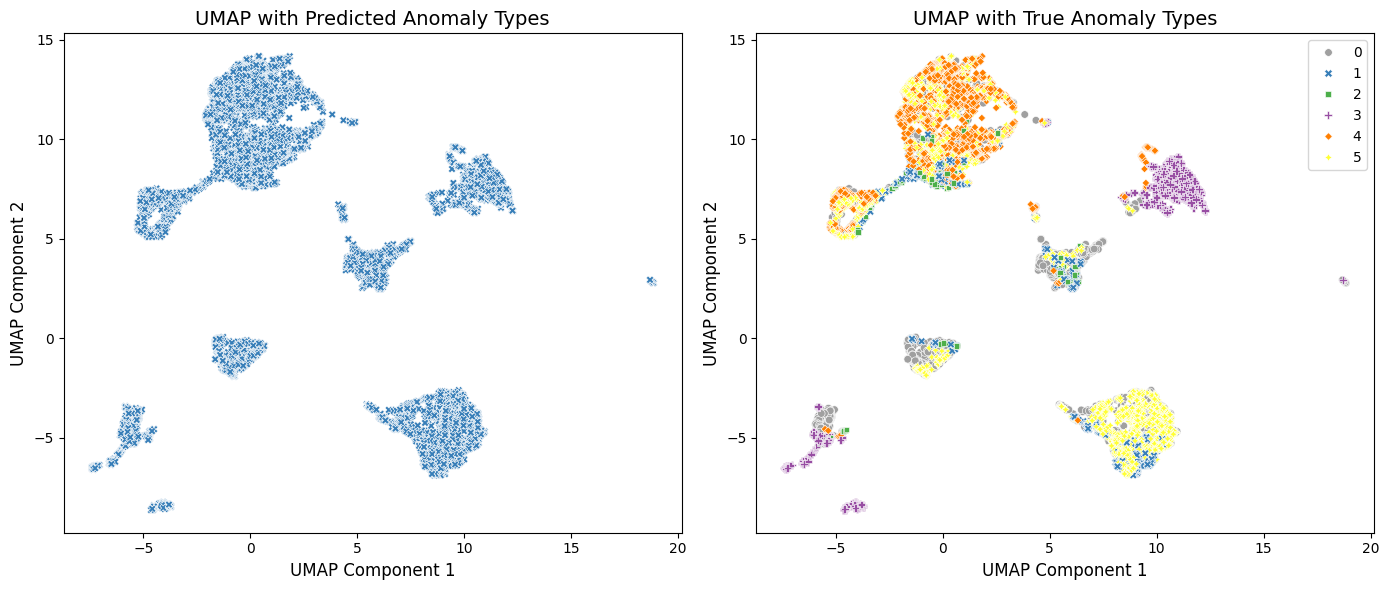

In [21]:
plot_comparison_anomalies(embedding, y_pred_test_a, y_pred_test_anomalies_a, custom_palette, all_labels, "UMAP", "figs/combined_model_predictions_anomalies_umap.png")

In [22]:
z_train_sampled, y_train_sampled, selected_indices = sample_data(z_train, y_train, n_samples=200000, anomaly_ratio=0.3)

[67879]
140000
24384055
140000


In [23]:
reducer = umap.UMAP()
reducer.fit(z_train_sampled)
reducer.embedding_.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(200000, 2)

In [24]:
test_embedding = reducer.transform(z_sampled)

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


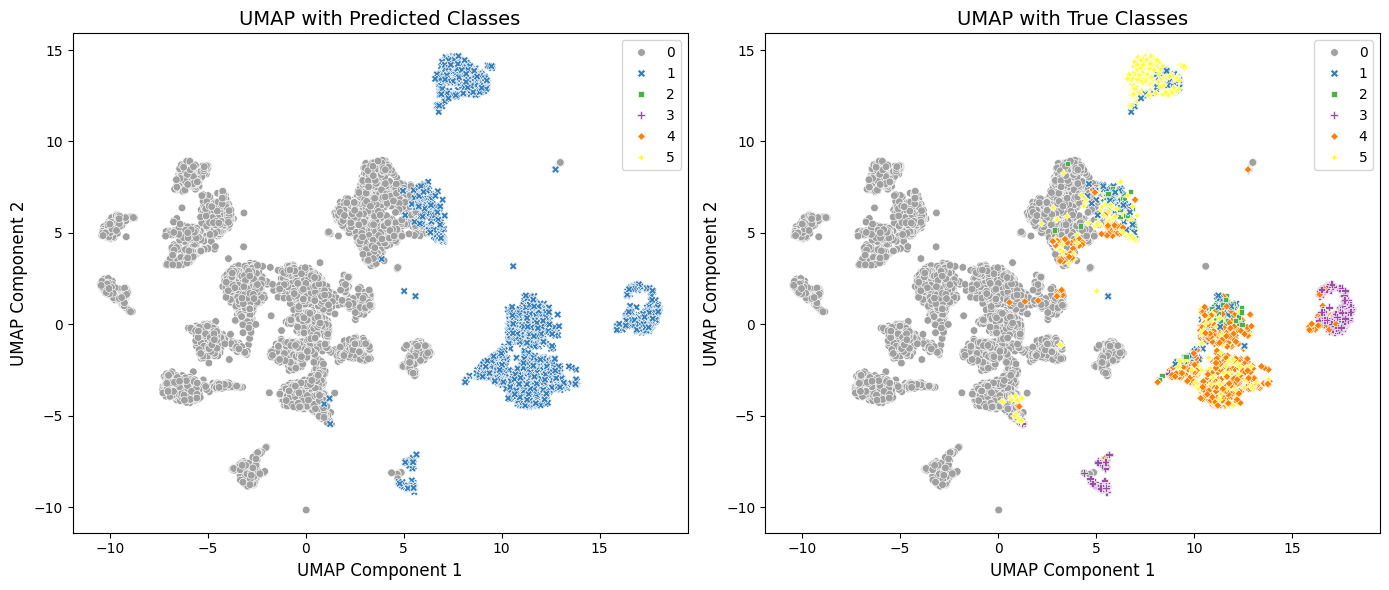

In [25]:
plot_comparison_all(test_embedding, y_pred_sampled, y_test_anomalies_sampled, 
                custom_palette, all_labels, "UMAP", save_path="figs/combined_model_bin_pred_classes_umap.png")

In [27]:
test_embedding = reducer.transform(z_test_a)
test_embedding.shape

/home/darosali/BP/amaretto/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(8865, 2)

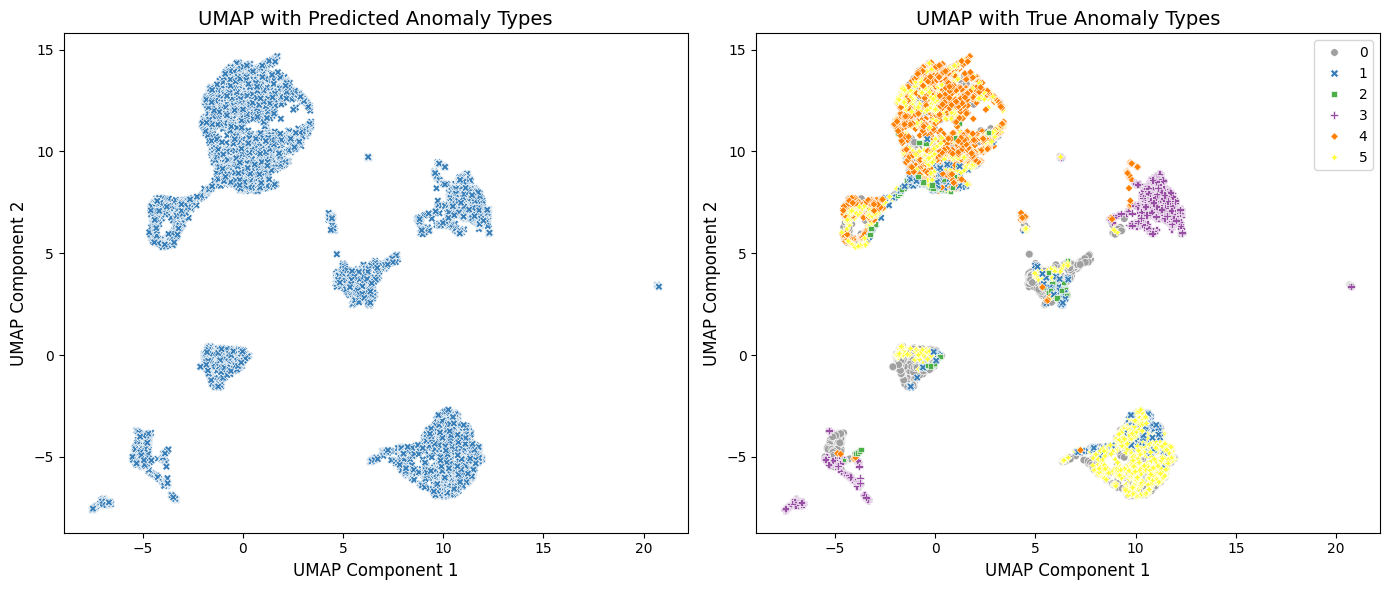

In [28]:
plot_comparison_anomalies(test_embedding, y_pred_test_a, y_pred_test_anomalies_a, custom_palette, all_labels, "UMAP", "figs/combined_model_predictions_anomalies_umap.png")

### Find best threshold

In [53]:
model.eval()
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
with torch.no_grad():
    _, y_logits, z_val = model(X_val_tensor)  # Assuming y_logits are raw scores (logits)
    y_probs_val = F.softmax(y_logits, dim=1)  # Convert logits to probabilities
    y_pred_val = torch.argmax(y_probs_val, dim=1)
    
y_probs_val = y_probs_val.cpu().numpy()
y_pred_val = y_pred_val.cpu().numpy()


In [54]:
best_f1, best_threshold = f1_smart(y_val, y_probs_val[:, 1])

In [55]:
print(classification_report(y_val, y_probs_val[:, 1] > best_threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2479693
           1       0.83      0.88      0.85      6708

    accuracy                           1.00   2486401
   macro avg       0.91      0.94      0.93   2486401
weighted avg       1.00      1.00      1.00   2486401



In [63]:
print(classification_report(y_train, y_probs_train[:, 1] > best_threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00  24384055
           1       0.59      0.90      0.71     67879

    accuracy                           1.00  24451934
   macro avg       0.80      0.95      0.86  24451934
weighted avg       1.00      1.00      1.00  24451934



In [65]:
print(classification_report(y_test, y_probs_test[:, 1] > best_threshold, digits=4))

              precision    recall  f1-score   support

           0     0.9997    0.9996    0.9996   2759074
           1     0.8325    0.8572    0.8447      6681

    accuracy                         0.9992   2765755
   macro avg     0.9161    0.9284    0.9222   2765755
weighted avg     0.9993    0.9992    0.9992   2765755



In [66]:
print(classification_report(y_test, y_pred_test, digits=4))

              precision    recall  f1-score   support

           0     0.9998    0.9990    0.9994   2759074
           1     0.6999    0.9288    0.7983      6681

    accuracy                         0.9989   2765755
   macro avg     0.8499    0.9639    0.8989   2765755
weighted avg     0.9991    0.9989    0.9989   2765755



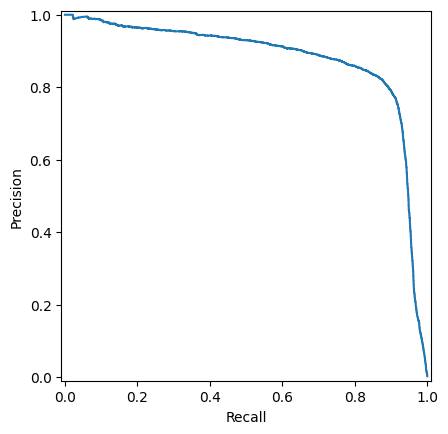

In [68]:
precision, recall, _ = precision_recall_curve(y_test, y_probs_test[:, 1])
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()